<a href="https://colab.research.google.com/github/sheezariaz2315/sheezariaz2315-urdu-ocr-codesaviours-si26-sheeza/blob/main/SI26_Week5_sheeza.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip -q install streamlit transformers==4.55.4 tokenizers==0.21.4 sentencepiece accelerate

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.0/42.0 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 96.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 87.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 119.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 39.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 121.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.20.0 requires huggingface-hub<2.0,>=1.2.0, but you have huggingface-hub 0.36.2 which is incompatible.


In [2]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
import torch

from PIL import Image
from transformers import TrOCRProcessor, VisionEncoderDecoderModel

In [4]:
model_path = "/content/drive/MyDrive/Urdu-OCR/trocr-urdu-model"

print("Model path:")
print(model_path)

print("\nFiles:")
print(os.listdir(model_path))

Model path:
/content/drive/MyDrive/Urdu-OCR/trocr-urdu-model

Files:
['vocab (1).json', 'tokenizer_config.json', 'config.json', 'vocab.json', 'merges.txt', 'preprocessor_config.json', 'generation_config.json', 'special_tokens_map.json', 'tokenizer.json', 'model.safetensors']


In [5]:
processor = TrOCRProcessor.from_pretrained(model_path)

model = VisionEncoderDecoderModel.from_pretrained(model_path)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.to(device)
model.eval()

print("Device:", device)
print("Model loaded successfully! ✅")

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


Device: cuda
Model loaded successfully! ✅


Saving signboard25.png to signboard25.png


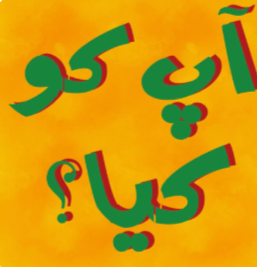

In [6]:
from google.colab import files

uploaded = files.upload()

image_path = list(uploaded.keys())[0]

image = Image.open(image_path).convert("RGB")

display(image)

In [7]:
pixel_values = processor(
    images=image,
    return_tensors="pt"
).pixel_values.to(device)

with torch.no_grad():

    generated_ids = model.generate(
        pixel_values,
        max_new_tokens=64,
        num_beams=4
    )

prediction = processor.batch_decode(
    generated_ids,
    skip_special_tokens=True
)[0]

print("Extracted Urdu Text:")
print(prediction)

Extracted Urdu Text:
����������������������������������������������������������������


In [9]:
print(prediction.encode("utf-8", errors="replace").decode("utf-8"))

����������������������������������������������������������������


In [22]:
%%writefile app.py

import streamlit as st
import torch
from PIL import Image
from transformers import TrOCRProcessor, VisionEncoderDecoderModel

st.set_page_config(
    page_title="Urdu OCR — Code Saviours SI-26",
    page_icon="📖"
)

st.title("Urdu OCR — Code Saviours SI-26")
st.write("Upload an image containing Urdu text and get the extracted text.")

model_path = "/content/drive/MyDrive/Urdu-OCR/trocr-urdu-model"

@st.cache_resource
def load_model():
    processor = TrOCRProcessor.from_pretrained(model_path)
    model = VisionEncoderDecoderModel.from_pretrained(model_path)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.eval()

    return processor, model, device

processor, model, device = load_model()

uploaded_file = st.file_uploader(
    "Upload Urdu Image",
    type=["png", "jpg", "jpeg"]
)

if uploaded_file is not None:

    image = Image.open(uploaded_file).convert("RGB")

    st.image(image, caption="Uploaded Image", use_container_width=True)

    if st.button("Extract Urdu Text"):

        pixel_values = processor(
            image,
            return_tensors="pt"
        ).pixel_values.to(device)

        with torch.no_grad():

            generated_ids = model.generate(
                pixel_values,
                max_new_tokens=64,
                num_beams=4
            )

        prediction = processor.batch_decode(
            generated_ids,
            skip_special_tokens=True
        )[0]

        st.subheader("Extracted Urdu Text")
        st.text_area(
            "Result",
            prediction,
            height=120
        )

Writing app.py


In [24]:
!ls -l app.py

-rw-r--r-- 1 root root 1627 Aug 13 20:16 app.py


In [10]:
!pip install -q streamlit

In [34]:
!streamlit run app.py --server.address 0.0.0.0 --server.port 8501 > /content/streamlit.log 2>&1 &

In [26]:
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 -O /content/cloudflared
!chmod +x /content/cloudflared

In [27]:
!cat /content/streamlit.log



2026-08-13 20:17:48.169 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://136.109.159.157:8501



In [28]:
!curl -I http://localhost:8501

HTTP/1.1 200 OK
date: Thu, 13 Aug 2026 20:19:20 GMT
server: uvicorn
content-type: text/html; charset=utf-8
accept-ranges: bytes
content-length: 10951
last-modified: Thu, 13 Aug 2026 19:56:06 GMT
etag: "7e08dab53b84f3f03ba05e018a978dc1"
cache-control: no-cache



In [37]:
!cloudflared tunnel --url http://127.0.0.1:8501

2026-08-13T20:25:55Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-08-13T20:25:55Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-08-13T20:26:00Z INF +--------------------------------------------------------------------------------------------+
2026-08-13T20:26:00Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
2026-08-13T20:26:00Z INF |  https://furniture-perform-remainder-conservation.tryc

In [38]:
%%writefile requirements.txt

streamlit
torch
transformers==4.55.4
tokenizers==0.21.4
sentencepiece
accelerate
Pillow

Writing requirements.txt


In [39]:
!ls -lh app.py requirements.txt

-rw-r--r-- 1 root root 1.6K Aug 13 20:16 app.py
-rw-r--r-- 1 root root   89 Aug 13 20:30 requirements.txt


In [40]:
from google.colab import files

files.download("/content/app.py")
files.download("/content/requirements.txt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>